## Problem Statement
In this project, I’m trying to understand why customers are leaving (churning) and what factors are driving that behavior.

Customer churn is a big problem for businesses because losing existing customers directly impacts revenue, and getting new customers usually costs more. So instead of just looking at numbers, the goal here is to actually dig into the data and figure out patterns — who is leaving, why they are leaving, and what kind of customers are more likely to stay.

The idea is to use this analysis to come up with insights that could help a business reduce churn and retain more customers.

## Data Loading & Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("data/processed/customer_churn_cleaned.csv")
df.head()

,CustomerID,Gender,Age,Under30,SeniorCitizen,Married,Dependents,NumberofDependents,Country,State,City,ZipCode,Latitude,Longitude,Population,Quarter,ReferredaFriend,Number_of_Referrals,TenureinMonths,Offer,PhoneService,AvgMonthlyLongDistanceCharges,MultipleLines,InternetService,InternetType,AvgMonthlyGBDownload,OnlineSecurity,OnlineBackup,DeviceProtectionPlan,PremiumTechSupport,StreamingTV,StreamingMovies,StreamingMusic,UnlimitedData,Contract,PaperlessBilling,PaymentMethod,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,CustomerStatus,ChurnLabel,ChurnScore,CLTV,ChurnCategory,ChurnReason,Churn,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,Los Angeles,90022,34.023810,-118.156582,68701,Q3,No,0,1,No Offer,No,0.00,No,Yes,DSL,8,No,No,Yes,No,No,Yes,No,No,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,0.00,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data,1,1,2,59.65,5,2,1,Stable
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,Los Angeles,90063,34.044271,-118.185237,55668,Q3,Yes,1,8,Offer E,Yes,48.85,Yes,Yes,Fiber Optic,17,No,Yes,No,No,No,No,No,Yes,Month-to-Month,Yes,Credit Card,80.65,633.30,0.00,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer,1,8,2,1024.10,4,2,2,Stable
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,Los Angeles,90065,34.108833,-118.229715,47534,Q3,No,0,18,Offer D,Yes,11.33,Yes,Yes,Fiber Optic,52,No,No,No,No,Yes,Yes,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,45.61,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer,1,18,4,1910.88,4,3,3,Stable
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,Inglewood,90303,33.936291,-118.332639,27778,Q3,Yes,1,25,Offer C,Yes,19.76,No,Yes,Fiber Optic,12,No,Yes,Yes,No,Yes,Yes,No,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,13.43,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services,1,25,5,2995.07,3,4,4,Stable
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,Whittier,90602,33.972119,-118.020188,26265,Q3,Yes,1,37,Offer C,Yes,6.33,Yes,Yes,Fiber Optic,14,No,No,No,No,No,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,0.00,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges,1,37,1,3102.36,3,2,4,Stable


In [4]:
df.shape

(7043, 58)

In [5]:
_ = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 58 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CustomerID                     7043 non-null   object 
 1   Gender                         7043 non-null   object 
 2   Age                            7043 non-null   int64  
 3   Under30                        7043 non-null   object 
 4   SeniorCitizen                  7043 non-null   object 
 5   Married                        7043 non-null   object 
 6   Dependents                     7043 non-null   object 
 7   NumberofDependents             7043 non-null   int64  
 8   Country                        7043 non-null   object 
 9   State                          7043 non-null   object 
 10  City                           7043 non-null   object 
 11  ZipCode                        7043 non-null   int64  
 12  Latitude                       7043 non-null   f

In [6]:
_ = df.describe()

In [7]:
df.describe().loc[['mean','min','max']]

,Age,NumberofDependents,ZipCode,Latitude,Longitude,Population,Number_of_Referrals,TenureinMonths,AvgMonthlyLongDistanceCharges,AvgMonthlyGBDownload,MonthlyCharge,TotalCharges,TotalRefunds,TotalExtraDataCharges,TotalLongDistanceCharges,TotalRevenue,SatisfactionScore,ChurnScore,CLTV,Churn,Recency,Frequency,Monetary,R_score,F_score,M_score
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.50504,4400.295755,0.26537,32.386767,3.064887,3034.379056,3.026125,3.0,3.0
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.00000,2003.000000,0.00000,1.000000,0.000000,21.360000,1.000000,1.0,1.0
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.00000,6500.000000,1.00000,72.000000,8.000000,11979.340000,5.000000,5.0,5.0


## Data Cleaning

Before doing any analysis, I cleaned the data to make sure everything is consistent and usable.

Some of the things I did here:
- Converted the `TotalCharges` column into numeric format because it had some issues
- Handled missing values in a few columns by assigning meaningful labels (like "No Offer" or "No Internet")
- Created a proper churn column (0 and 1) from the existing churn label

In [8]:
_ = df.isnull().sum()

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [10]:
df['Offer'] = df['Offer'].fillna('No Offer')

In [11]:
df['InternetType'] = df['InternetType'].fillna('No Internet')

In [12]:
df['ChurnReason'] = df['ChurnReason'].fillna('No Churn')
df['ChurnCategory'] = df['ChurnCategory'].fillna('No Churn')

In [13]:
_ = df.isnull().sum()

## Churn Distribution

Here, I looked at how many customers actually churned compared to those who stayed.

This gives a quick overall idea of the problem — whether churn is high or low — and also helps in understanding if the dataset is balanced or not.

In [14]:
df['Churn'] = df['ChurnLabel'].map({'Yes':1, 'No':0})

df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [15]:
df["ChurnLabel"].value_counts(normalize=True)*100

ChurnLabel
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [16]:
df['Churn'] = df['Churn'].astype(int)

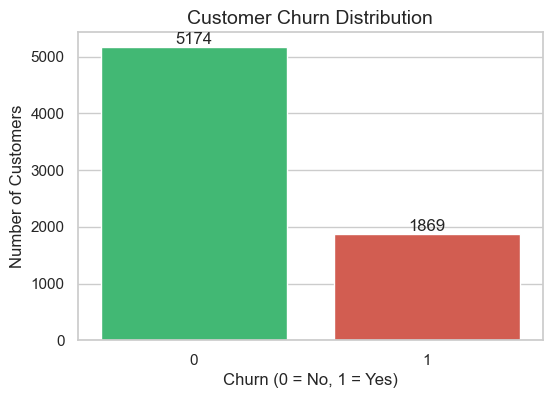

In [17]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x='Churn', data=df, hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom')

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

### Revenue Impact Analysis

In this section, I tried to understand how churn is affecting the company’s revenue.

Instead of just counting customers, I looked at:
- how much revenue is coming from different types of customers
- how much revenue is being lost due to churn
- and how factors like contract type influence both revenue and churn

This helps in identifying which customers are more valuable and where the business is losing the most money.

In [18]:
total_revenue = df['TotalRevenue'].sum()
churned_revenue = df[df['Churn'] == 1]['TotalRevenue'].sum()
retained_revenue = df[df['Churn'] == 0]['TotalRevenue'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Revenue from Churned Customers: ${churned_revenue:,.2f}")
print(f"Revenue from Retained Customers: ${retained_revenue:,.2f}")
print("Revenue Loss %:", round((churned_revenue / total_revenue) * 100, 2))

Total Revenue: $21,371,131.69
Revenue from Churned Customers: $3,684,459.82
Revenue from Retained Customers: $17,686,671.87
Revenue Loss %: 17.24


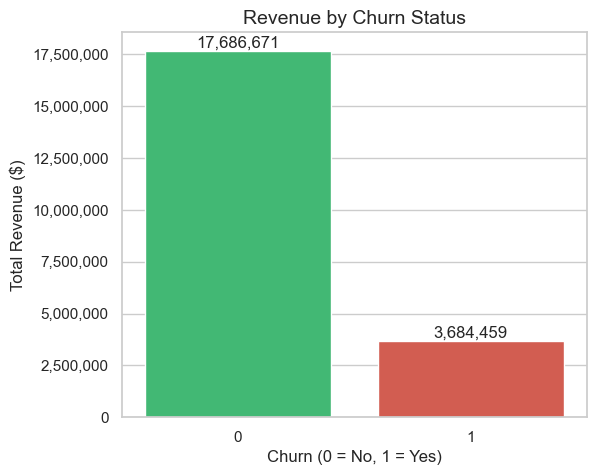

In [19]:
import matplotlib.ticker as ticker
plt.figure(figsize=(6,5))

revenue_data = df.groupby('Churn')['TotalRevenue'].sum().reset_index()

ax = sns.barplot(
    x='Churn', 
    y='TotalRevenue', 
    data=revenue_data,
    hue='Churn',
    palette=['#2ecc71', '#e74c3c'],
    legend=False)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x):,}'))

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Revenue by Churn Status", fontsize=14)
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Total Revenue ($)")

plt.show()

In [20]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,0,1
Contract,,
Month-to-Month,54.155125,45.844875
One Year,89.290323,10.709677
Two Year,97.450876,2.549124


In [21]:
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100

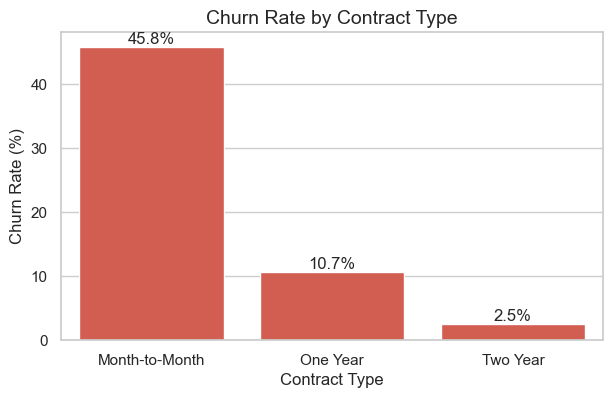

In [22]:
plt.figure(figsize=(7,4))

contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()
contract_churn['Churn'] = contract_churn['Churn'] * 100

ax = sns.barplot(
    x='Contract',
    y='Churn',
    data=contract_churn,
    color='#e74c3c')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%', 
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Churn Rate by Contract Type", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.show()

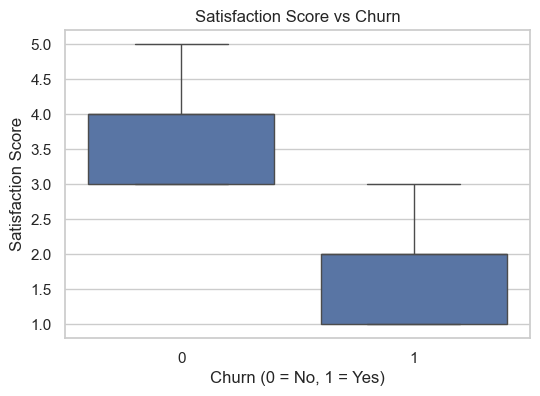

In [23]:
plt.figure(figsize=(6,4))

ax = sns.boxplot(x='Churn', y='SatisfactionScore', data=df)

plt.title("Satisfaction Score vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Satisfaction Score")

plt.show()

### CHURN REASON ANALYSIS

Here, I focused on understanding the actual reasons behind customer churn.

Instead of guessing, the dataset provides specific churn reasons, so I analyzed which ones appear most frequently.

This gives a much clearer picture of what’s going wrong — whether it's pricing, service quality, or something else — and helps in thinking about possible solutions.

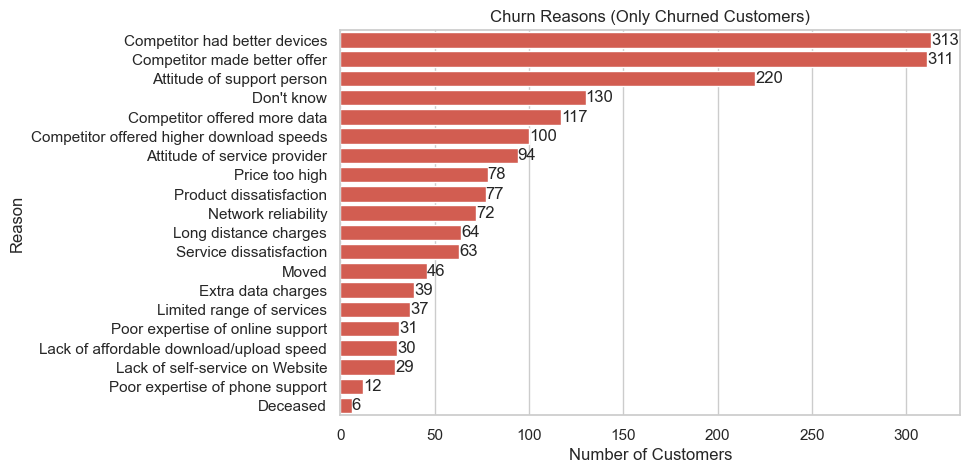

In [24]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    y='ChurnReason', 
    data=df[df['Churn'] == 1],
    order=df[df['Churn'] == 1]['ChurnReason'].value_counts().index,
    color='#e74c3c')

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_width())}', 
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', va='center'
    )

plt.title("Churn Reasons (Only Churned Customers)")
plt.xlabel("Number of Customers")
plt.ylabel("Reason")

plt.show()

### RFM SEGMENTATION

Since the dataset does not contain the exact last transaction date, I used tenure as a proxy for recency.

- Recency → Approximated using tenure (customers with lower tenure are considered more likely to churn)
- Frequency → Number of services/products used by the customer
- Monetary → Total revenue generated by the customer

In [25]:
# Recency (lower tenure = more risky)
df['Recency'] = df['TenureinMonths']

# Frequency (number of services used)
services = ['OnlineSecurity','OnlineBackup', 'DeviceProtectionPlan','PremiumTechSupport','StreamingTV','StreamingMovies','StreamingMusic', 'UnlimitedData']

df['Frequency'] = df[services].apply(lambda x: sum(x == 'Yes'), axis=1)

# Monetary (total revenue)
df['Monetary'] = df['TotalRevenue']

In [26]:
df[['Recency','Frequency','Monetary']].head()

,Recency,Frequency,Monetary
0,1,2,59.65
1,8,2,1024.10
2,18,4,1910.88
3,25,5,2995.07
4,37,1,3102.36


In [27]:
# Recency
df['R_score'] = pd.qcut(df['Recency'], 5, labels=[5,4,3,2,1])

# Frequency (rank-based)
df['F_score'] = pd.qcut(df['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

# Monetary
df['M_score'] = pd.qcut(df['Monetary'], 5, labels=[1,2,3,4,5])

In [28]:
df[['Recency','Frequency','Monetary','R_score','F_score','M_score']].head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
0,1,2,59.65,5,2,1
1,8,2,1024.10,4,2,2
2,18,4,1910.88,4,3,3
3,25,5,2995.07,3,4,4
4,37,1,3102.36,3,2,4


### CREATING CUSTOMER SEGMENTS

Based on the RFM scores, I grouped customers into different segments:

- Champions → High recency and high engagement  
- At Risk → High value customers but not active recently  
- Churning → Low engagement and likely to leave  
- Stable → Remaining customers with average behavior  

This segmentation helps in quickly identifying which customers are valuable and which ones need attention.

In [29]:
def segment(row):
    
    # Champions
    if row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Champions'
    
    # At Risk (high value but not recent)
    elif row['R_score'] <= 2 and row['M_score'] >= 4:
        return 'At Risk'
    
    # Churning (low engagement + low value)
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'Churning'
    
    # Stable
    else:
        return 'Stable'

In [30]:
df['Segment'] = df.apply(segment, axis=1)
df['Segment'].value_counts()

Segment
Stable       3875
At Risk      2277
Champions     549
Churning      342
Name: count, dtype: int64

In [31]:
(pd.crosstab(df['Segment'], df['Churn'], normalize='index') * 100).round(2)

Churn,0,1
Segment,,
At Risk,87.62,12.38
Champions,55.37,44.63
Churning,97.37,2.63
Stable,65.60,34.40


In [32]:
df.groupby('Segment')['TotalRevenue'].sum().sort_values(ascending=False)

Segment
At Risk      14830406.70
Stable        5260309.31
Churning       725670.10
Champions      554745.58
Name: TotalRevenue, dtype: float64

In [33]:
df.groupby('Segment')['CLTV'].mean()

Segment
At Risk      5033.339482
Champions    3984.910747
Churning     4792.821637
Stable       4052.518194
Name: CLTV, dtype: float64

In [34]:
pd.crosstab(df['Segment'], df['Churn'])

Churn,0,1
Segment,,
At Risk,1995,282
Champions,304,245
Churning,333,9
Stable,2542,1333


In [35]:
pd.crosstab(df['Segment'], df['Churn'], normalize='index') * 100

Churn,0,1
Segment,,
At Risk,87.615283,12.384717
Champions,55.373406,44.626594
Churning,97.368421,2.631579
Stable,65.600000,34.400000


C:\Users\Acer\AppData\Local\Temp\ipykernel_31108\2939987781.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


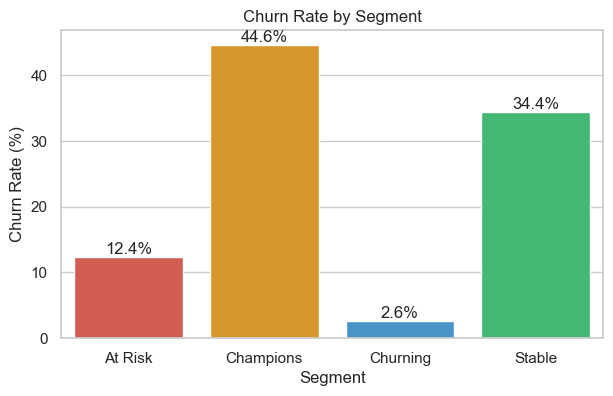

In [36]:
segment_churn = pd.crosstab(df['Segment'], df['Churn'], normalize='index') * 100
segment_churn = segment_churn[1].reset_index()

plt.figure(figsize=(7,4))

ax = sns.barplot(
    x='Segment',
    y=1,
    data=segment_churn,
    palette=['#e74c3c','#f39c12','#3498db','#2ecc71']
)

# Add labels
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Churn Rate by Segment")
plt.xlabel("Segment")
plt.ylabel("Churn Rate (%)")

plt.show()

## Final Conclusion

From the overall analysis, it’s clear that customer churn is not random and there are clear patterns behind it.

The segmentation showed that **At Risk customers** contribute the highest revenue but are not very active, making them the most important group to focus on. At the same time, **Champions also show a relatively high churn rate**, which means even valuable customers can leave if not properly engaged.

Looking at churn reasons, most customers are leaving due to **better offers and services from competitors**, along with issues related to **customer support and pricing**. This shows that both external competition and internal service quality play a big role in churn.

Overall, the analysis suggests that focusing on high-value but inactive customers, improving customer experience, and offering competitive pricing can help reduce churn and protect revenue.